# 🎓 Predicting Student Mental Health Score from Social Media Usage

**Problem:** We're predicting a student's `Mental_Health_Score` (a continuous score from ~3 to ~10) using their social media habits, study time, sleep, physical activity, and stress level. This is a **regression** problem since the target is a number, not a category.

**Dataset:** `Student_Social_Media_And_Mental_Health_Impact.csv` — 5,000 students, 13 columns covering demographics (Age, Gender, Country), platform usage (Avg_Daily_Usage_Hours, Daily_Unlocks, Most_Used_Platform), lifestyle (Study_Hours, Sleep_Hours_Per_Night, Physical_Activity_Hours), and Stress_Level.



## 1. Import Libraries

We're grouping imports by purpose: data handling, visualization, preprocessing, models, evaluation, and saving. Keeping imports grouped like this makes it easy to see at a glance what the notebook is going to do.

In [181]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##  Load the Dataset

In [182]:
df = pd.read_csv("Student Social Media And Mental Health Impact.csv")


In [183]:
# Row and cols
df.shape

(5000, 13)

In [184]:
# check 1st 5 rows
df.head(5)

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [185]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   str    
 2   Country                  5000 non-null   str    
 3   Academic_Level           5000 non-null   str    
 4   Most_Used_Platform       5000 non-null   str    
 5   Purpose_Of_Use           5000 non-null   str    
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   str    
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), str(6)
memory usage: 736.5 KB


In [186]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [187]:
df.duplicated().sum()

np.int64(2)

In [188]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


## EDA Perform

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

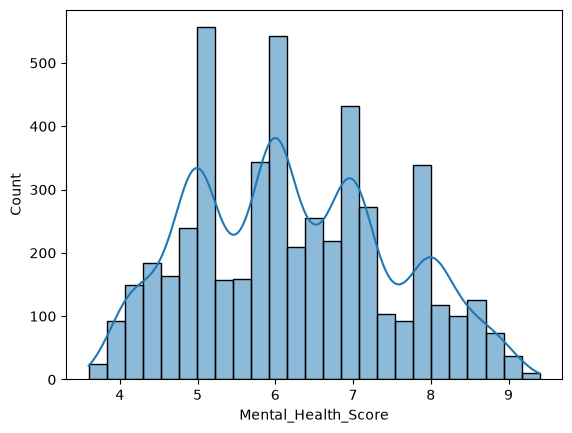

In [189]:
sns.histplot(df["Mental_Health_Score"],kde=True)

<Axes: >

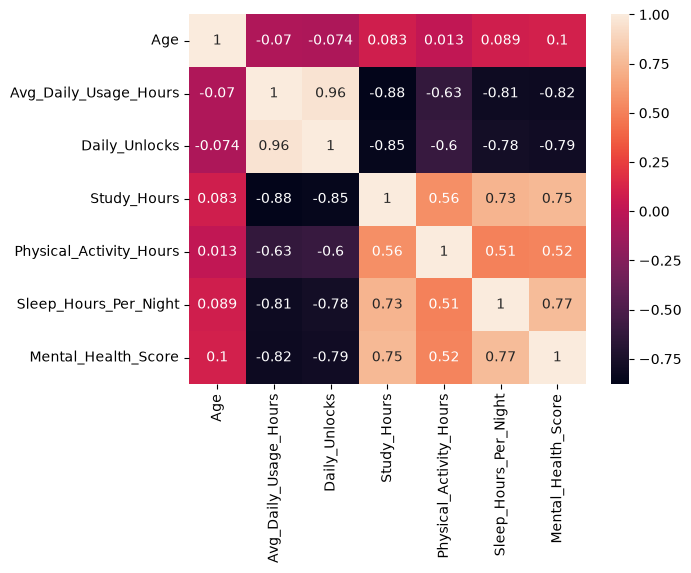

In [190]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [191]:
df["Stress_Level"].unique()

<ArrowStringArray>
['Medium', 'Low', 'Very High', 'High']
Length: 4, dtype: str

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

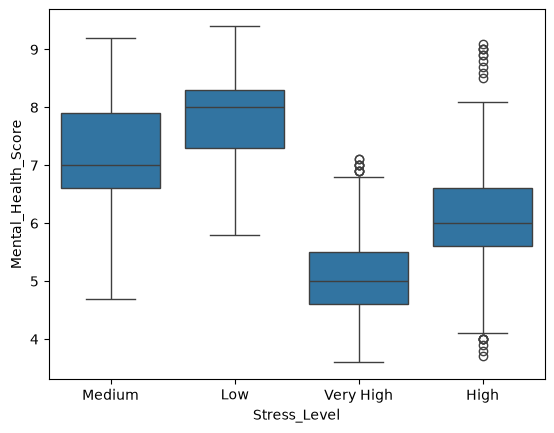

In [192]:
orde=['Medium', 'Low', 'Very High', 'High']
sns.boxplot(x="Stress_Level", y="Mental_Health_Score",  data=df, order=orde)

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

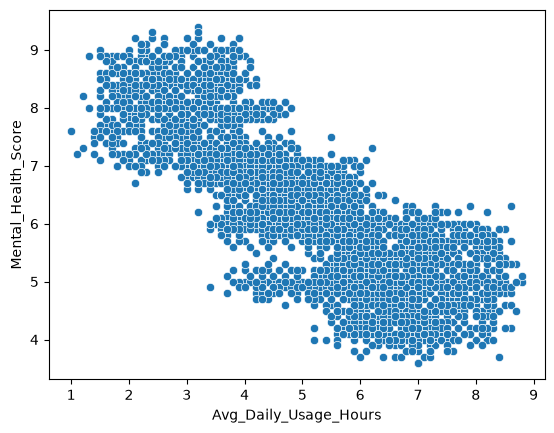

In [193]:
sns.scatterplot(
    x="Avg_Daily_Usage_Hours",
    y="Mental_Health_Score",
    data=df
)

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

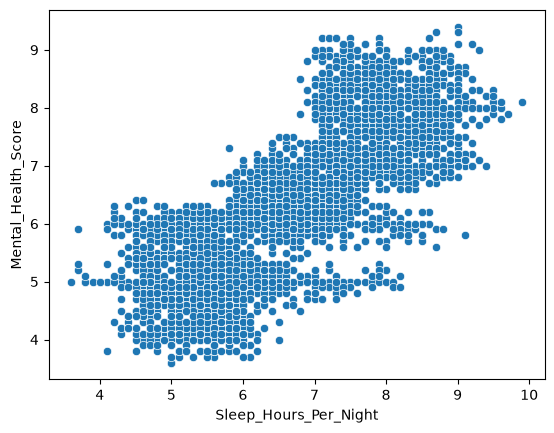

In [194]:
sns.scatterplot(
    x="Sleep_Hours_Per_Night",
    y="Mental_Health_Score",
    data=df
)

In [195]:
df["Most_Used_Platform"].unique()

<ArrowStringArray>
[ 'Facebook',  'LinkedIn', 'Instagram',  'Snapchat',   'Twitter',   'YouTube',
    'TikTok',      'LINE', 'KakaoTalk', 'VKontakte',  'WhatsApp',    'WeChat']
Length: 12, dtype: str

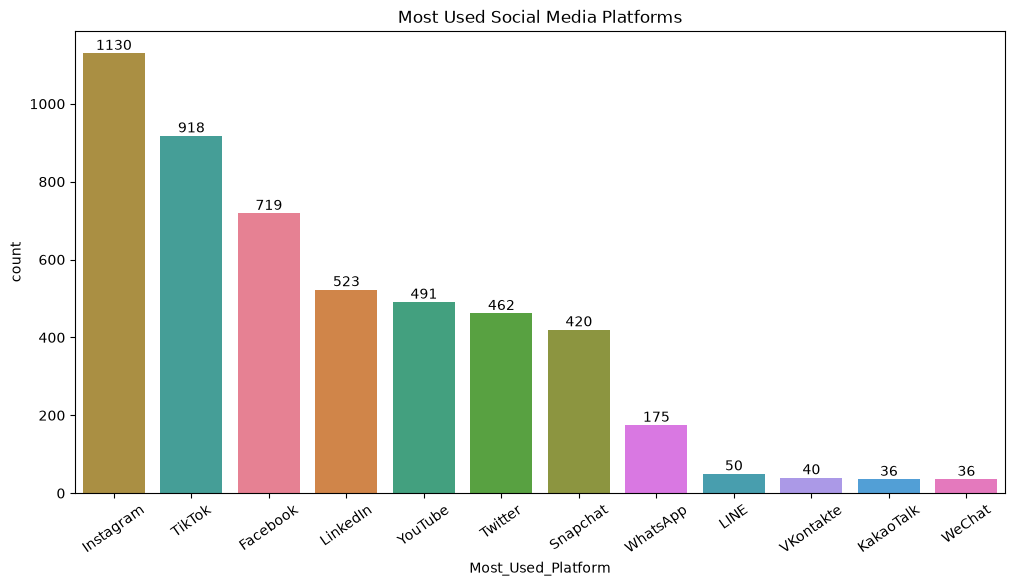

In [196]:


plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=df,
    x="Most_Used_Platform",
     hue="Most_Used_Platform",
    order=df["Most_Used_Platform"].value_counts().index
)

# Show count on top of each bar
for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=35)
plt.title("Most Used Social Media Platforms")


plt.show()

## Checking Outliers

In [197]:
# Through IQR
num_cols = df.select_dtypes(include=["number"])

In [198]:
num_cols

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
0,21,4.0,134,4.5,2.2,6.7,6.8
1,23,1.6,73,7.0,2.4,8.6,7.6
2,22,4.6,166,4.0,1.8,6.7,7.0
3,18,7.0,220,1.0,1.7,5.4,5.3
4,24,7.5,237,1.0,1.1,5.0,4.4
...,...,...,...,...,...,...,...
4995,18,1.9,89,6.1,2.2,7.9,7.9
4996,18,6.6,216,2.3,1.8,6.0,4.7
4997,19,3.8,151,5.4,1.4,7.5,7.0
4998,18,3.8,119,4.0,1.5,6.4,6.7


In [199]:
# IQR formula
Q1 = num_cols.quantile(0.25)
Q3 = num_cols.quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR


outlier = (num_cols < lower_bound) | (num_cols> upper_bound)

print(outlier.sum())




Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


## Data Cleaning

In [200]:
# Drop duplicate values
df.drop_duplicates(inplace=True)
df.duplicated().sum()


np.int64(0)

In [201]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.750760,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.668406,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [202]:
# convert negative to realistic by using clip
df["Physical_Activity_Hours"]=df["Physical_Activity_Hours"].clip(lower=0)


In [203]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


## Skewness / Distribution

In [204]:
num_cols.skew()
# near to 0 -> centralized(0.01. 0.06)
# negative to 0 -> left skewed(-1.24)
# positive to 0 -> greater than  0 ----> right skewed (1.24)
# log tranformation through

Age                        0.155325
Avg_Daily_Usage_Hours      0.005606
Daily_Unlocks              0.002351
Study_Hours                0.435819
Physical_Activity_Hours    0.039971
Sleep_Hours_Per_Night      0.124050
Mental_Health_Score        0.206567
dtype: float64

## Feature Engineering


In [227]:
top_countries = df["Country"].value_counts().index[:10].to_list()
top_countries

['Other',
 'India',
 'USA',
 'Canada',
 'Australia',
 'UK',
 'Germany',
 'Mexico',
 'Turkey',
 'France']

In [206]:
def group_country(country):
    if country in top_countries:
        return country
    else: 
        return "Other"
    

In [207]:
df["grouped_country"]=df["Country"].apply(group_country)

In [208]:
df["grouped_country"].value_counts()

grouped_country
Other        3231
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

## Encoding 

In [209]:
df.head(20)

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score,grouped_country
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8,Other
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6,Other
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0,Canada
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3,Other
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4,Other
5,19,Female,Other,Undergraduate,Twitter,News,4.1,138,4.6,2.2,6.8,Low,6.8,Other
6,22,Female,Other,Undergraduate,Instagram,Entertainment,8.0,246,1.0,0.9,5.2,Very High,5.3,Other
7,21,Female,Other,Undergraduate,Facebook,Networking,6.0,209,1.0,1.3,5.7,High,4.7,Other
8,24,Male,USA,Graduate,YouTube,Education,4.7,154,2.4,1.1,7.0,High,6.2,USA
9,19,Male,Other,Undergraduate,TikTok,Entertainment,3.6,130,3.7,1.1,8.1,Medium,8.6,Other


In [210]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score', 'grouped_country'],
      dtype='str')

In [211]:
skwed_col = ["Study_Hours"] # perform skew
other_num_col = ['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 
       'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       ]  #Do only just scaling/normalization 
ordinal_col = ["Stress_Level"] #Do ordinal encoding becuse of oder
normal_col = ["Gender","Academic_Level","Most_Used_Platform", "Purpose_Of_Use","grouped_country"]

feauture_col = skwed_col+other_num_col+ordinal_col+normal_col
x= df[feauture_col]
y = df["Mental_Health_Score"]

## Now create pipeline

In [212]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split



#1. Skwes Pipeline
skew_pipeline = Pipeline(steps=[
("log_Tranformation" , FunctionTransformer(np.log1p)),
("Scale" , StandardScaler())

])

# 2. numeric Feature
plain_pipeline = Pipeline(steps=[
    ("scale", StandardScaler())
])

# 3. Ordinal
ordinal_pipeline = Pipeline(steps=[
    ("encode" ,OrdinalEncoder(categories=[["Low", "Medium", "High", "Very High"]]))
])


# 4. Normal Feature
normal_pipeline = Pipeline(steps=[
    ("encode" , OneHotEncoder(handle_unknown="ignore"))
# handle_unknown="ignore" ignore null or empty value if there are in catergorical cols
])

X_train, X_test, y_train, y_test = train_test_split( x, y, test_size=0.30, random_state=42)

preprocessor=ColumnTransformer(transformers=[
    ("skew",skew_pipeline, skwed_col ),
    ("numeric", plain_pipeline, other_num_col),
    ("ordinal", ordinal_pipeline, ordinal_col),
    ("categorical", normal_pipeline, normal_col)
])

## Build Pipeline
data processing + model calling

In [213]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

lr_pipeline = Pipeline(steps=[
    ("preprocessor",preprocessor ),
    ("Regression",LinearRegression())

])

lr_pipeline.fit(X_train,y_train)
lr_predict = lr_pipeline.predict(X_test)
lr_predict_train = lr_pipeline.predict(X_train)
lr_r2_testing = r2_score(y_test, lr_predict)
lr_r2_traning = r2_score(y_train,lr_predict_train)

lr_mae = mean_absolute_error(y_test,lr_predict)



print(f"Accuracy of Traning {lr_r2_traning}")
print(f"Accuracy of Testing {lr_r2_testing}")
print(f"MAE {lr_mae}")



Accuracy of Traning 0.7236771199387539
Accuracy of Testing 0.739794461743302
MAE 0.5361775634720183


### Random Forest 

In [214]:
from sklearn.ensemble import RandomForestRegressor
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("random forest",RandomForestRegressor(random_state=42) )

])


rf_pipeline.fit(X_train, y_train)

rf_predict = rf_pipeline.predict(X_test)
rf_predict_training = rf_pipeline.predict(X_train)

rf_score_testing = r2_score(y_test,rf_predict)
rf_score_training = r2_score(y_train,rf_predict_training)

rf_mae = mean_absolute_error(y_test,rf_predict)


print(f"Accuracy of Traning {rf_score_training}")
print(f"Accuracy of testing {rf_score_testing}")
print(f"MAE {rf_mae}")


Accuracy of Traning 0.9809069341581819
Accuracy of testing 0.8780167461546369
MAE 0.34650236666666673


## Hyper Parameter Tunning

In [218]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "random forest__n_estimators": [100, 200, 300],
    "random forest__max_depth": [5, 10, 15],
    "random forest__min_samples_split": [2, 5, 10],
    "random forest__min_samples_leaf": [1, 2, 4],
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=15,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'random forest__max_depth': [5, 10, ...], 'random forest__min_samples_leaf': [1, 2, ...], 'random forest__min_samples_split': [2, 5, ...], 'random forest__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` dire

In [219]:
random_search.best_params_

{'random forest__n_estimators': 200,
 'random forest__min_samples_split': 5,
 'random forest__min_samples_leaf': 2,
 'random forest__max_depth': 15}

In [ ]:
rf_best_pipeline =random_search.best_estimator_
rf_best_pipeline

rf_best_predict = rf_best_pipeline.predict(X_test)

print(f"The R2 score {r2_score(y_test,rf_best_predict)}")
print(f"MAE score {mean_absolute_error(y_test,rf_best_predict)}")

The R2 score 0.8652257547733472
MAE score 0.36866505007865863


# Evaluation Model

In [222]:
from sklearn.metrics import mean_squared_error

# calculate rmse for linear regression
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predict))

# now random forest defualt version
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predict))

# now for the tunned
# Calculate RMSE for tuned Random Forest

rf_tuned_preds = random_search.best_estimator_.predict(X_test)
rf_tuned_rmse = np.sqrt(mean_squared_error(y_test, rf_tuned_preds))

rf_tuned_training_preds = random_search.best_estimator_.predict(X_train)
rf_tuned_training = r2_score(y_train, rf_tuned_training_preds)

rf_tuned_mae = mean_absolute_error(y_test, rf_tuned_preds)
rf_tuned_r2 = r2_score(y_test, rf_tuned_preds)


# Create a DataFrame to consolidate results

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (default)', 'Random Forest (tuned)'],
    'R2': [lr_r2_testing, rf_score_testing, rf_tuned_r2],
    'Training R2': [lr_r2_traning, rf_score_training, rf_tuned_training],
    'MAE': [lr_mae, rf_mae, rf_tuned_mae],
    'RMSE': [lr_rmse, rf_rmse, rf_tuned_rmse]
})

results

,Model,R2,Training R2,MAE,RMSE
0,Linear Regression,0.739794,0.723677,0.536178,0.676032
1,Random Forest (default),0.878017,0.980907,0.346502,0.462870
2,Random Forest (tuned),0.865226,0.954656,0.368665,0.486533


## save model

In [223]:
import joblib
joblib.dump(rf_pipeline, "Mental_Health_Model.pkl")


['Mental_Health_Model.pkl']

In [224]:
df.columns.to_list()

['Age',
 'Gender',
 'Country',
 'Academic_Level',
 'Most_Used_Platform',
 'Purpose_Of_Use',
 'Avg_Daily_Usage_Hours',
 'Daily_Unlocks',
 'Study_Hours',
 'Physical_Activity_Hours',
 'Sleep_Hours_Per_Night',
 'Stress_Level',
 'Mental_Health_Score',
 'grouped_country']